In [ ]:
!pip install tensorflow==2.15.0 -q
!pip install wfdb imbalanced-learn neurokit2 -q
!pip install numpy==1.26.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 3.4 MB/s eta 0:00:00:00:01m00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 28.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 25.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have tensorflow 2.15.0 which is incompatible.
jax 0.5.2 requires ml_dtypes>=0.4.0, but you have ml-dtypes 0.2.0 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
tf-keras 2.18.0 r

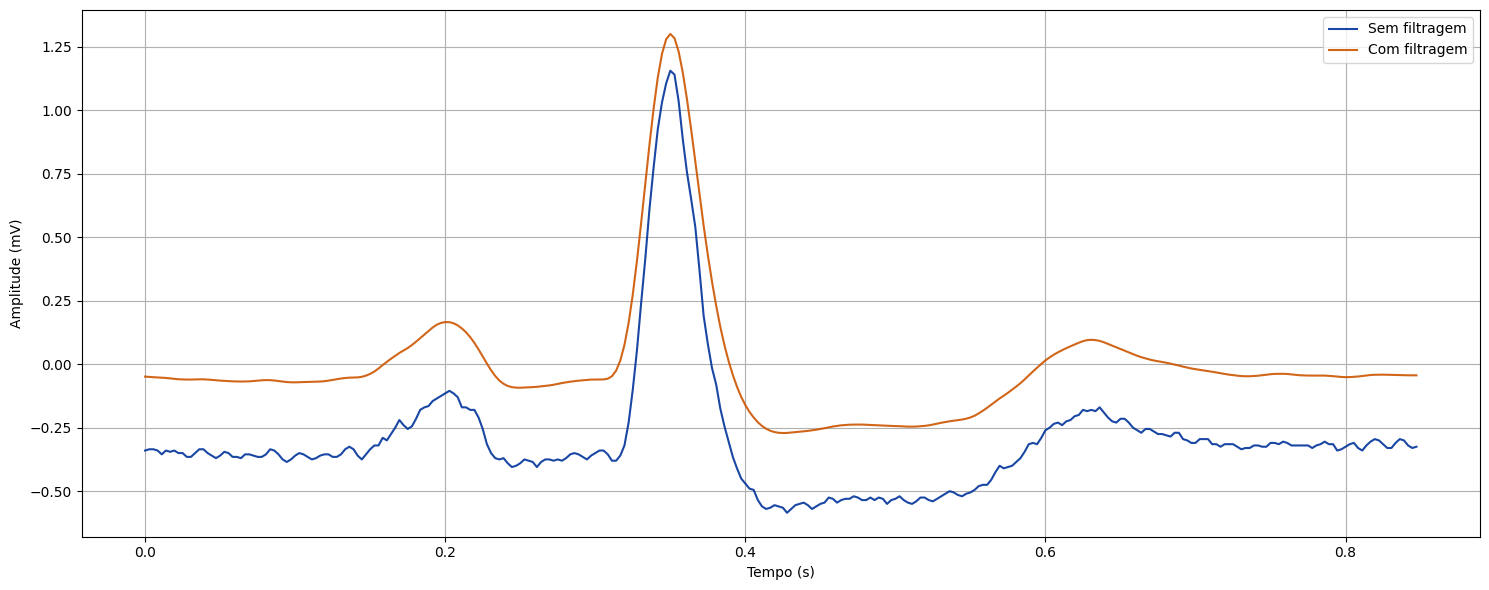

In [ ]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# Parâmetros
SAMPLING_RATE = 360
WINDOW_SIZE = 306
R_PEAK_OFFSET_LEFT = 126
R_PEAK_OFFSET_RIGHT = 180
TARGET_CLASS = 'N'
NUM_BEATS = 5
data_path = '/kaggle/input/mit-bih'
record_name = '105'
record_path = os.path.join(data_path, record_name)

# Carrega sinal e anotações
record = wfdb.rdrecord(record_path)
annotation = wfdb.rdann(record_path, 'atr')
signal_raw = record.p_signal[:, 0]
peaks = annotation.sample
symbols = annotation.symbol

# Filtragem
signal_filtered = nk.ecg_clean(signal_raw, sampling_rate=SAMPLING_RATE, method="neurokit",powerline=60)

# Coleta 5 batimentos da classe N
raw_segments = []
filtered_segments = []
for idx, peak in enumerate(peaks):
    if symbols[idx] != TARGET_CLASS:
        continue
    start = peak - R_PEAK_OFFSET_LEFT
    end = peak + R_PEAK_OFFSET_RIGHT
    if start >= 0 and end < len(signal_raw):
        raw_segments.append(signal_raw[start:end])
        filtered_segments.append(signal_filtered[start:end])
    if len(raw_segments) == NUM_BEATS:
        break

# Verifica se foram encontrados 5 batimentos válidos
if len(raw_segments) < NUM_BEATS:
    print(f"Apenas {len(raw_segments)} batimentos da classe '{TARGET_CLASS}' encontrados no registro {record_name}.")
else:
    # Eixo de tempo em segundos
    tempo = np.arange(WINDOW_SIZE) / SAMPLING_RATE

    # Plotagem com laranja escuro e azul escuro
    plt.figure(figsize=(15, 6))
    plt.plot(tempo, raw_segments[2], label='Sem filtragem', color= '#003399', alpha=0.9)
    plt.plot(tempo, filtered_segments[2], label='Com filtragem', color='#cc5500', alpha=0.9)
   # plt.title(f'Batimento {2 + 1} da classe {TARGET_CLASS} – Registro {record_name}')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Amplitude (mV)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("batimento_filtrado_vs_nao_filtrado.png", dpi=300)
    plt.show()


### Testes computacionais:

### Desbalanceado:

TF: 2.15.0

Filtrando sinais...

Segmentando...

Distribuição original:
Counter({0: 75017, 1: 8071, 2: 7255, 3: 7129, 4: 2546})

Normalizando...

Split 60/20/20

Train:
Counter({0: 45010, 1: 4842, 2: 4353, 3: 4277, 4: 1528})

Val:
Counter({0: 15003, 1: 1615, 2: 1451, 3: 1426, 4: 509})

Test:
Counter({0: 15004, 1: 1614, 2: 1451, 3: 1426, 4: 509})

NPZ gerado com dados de TREINO!
Shape x_test: (60010, 306, 1)
Shape y_test: (60010,)


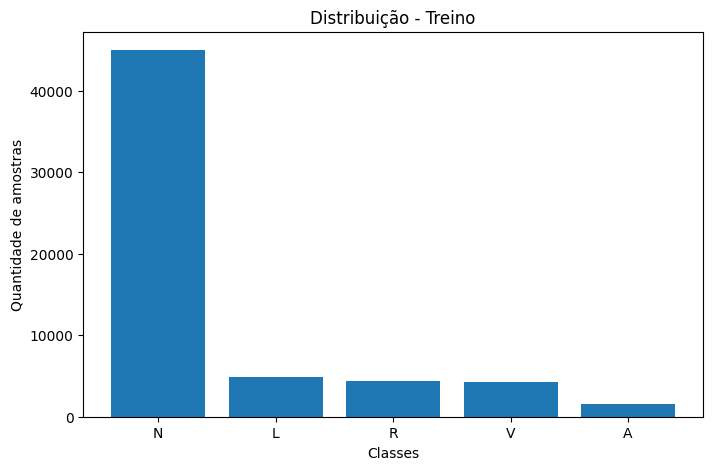

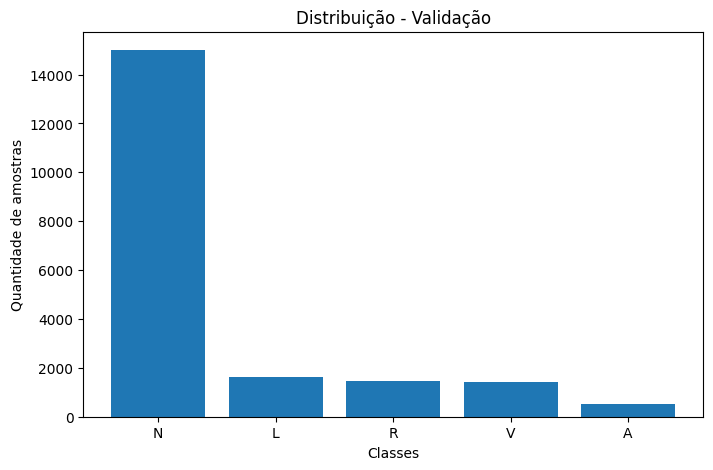

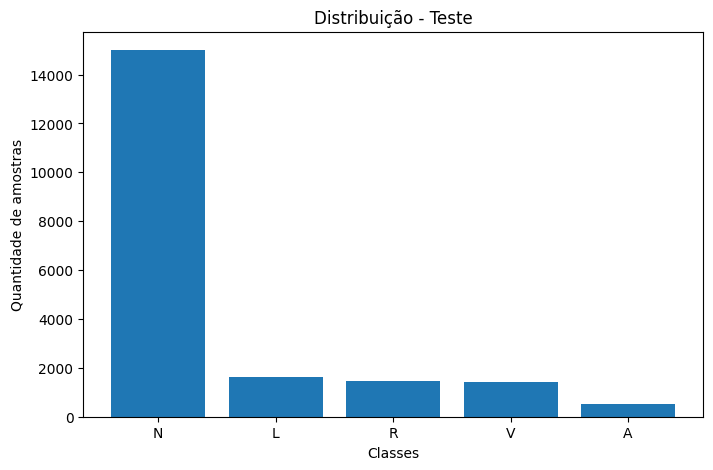


================ MODELO ================

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 306, 1)]          0         
                                                                 
 conv1d_8 (Conv1D)           (None, 302, 8)            48        
                                                                 
 max_pooling1d_8 (MaxPoolin  (None, 151, 8)            0         
 g1D)                                                            
                                                                 
 dropout_12 (Dropout)        (None, 151, 8)            0         
                                                                 
 conv1d_9 (Conv1D)           (None, 147, 16)           656       
                                                                 
 max_pooling1d_9 (MaxPoolin  (None, 73, 16)            0         
 g1D)           

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


626/626 [==============================] - 2s 4ms/step


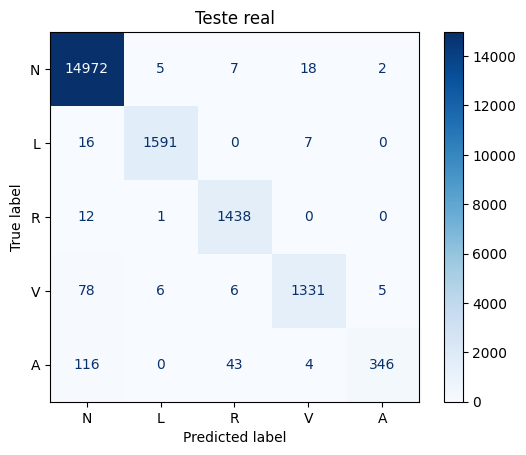


Classification Report:

              precision    recall  f1-score   support

           N       0.99      1.00      0.99     15004
           L       0.99      0.99      0.99      1614
           R       0.96      0.99      0.98      1451
           V       0.98      0.93      0.96      1426
           A       0.98      0.68      0.80       509

    accuracy                           0.98     20004
   macro avg       0.98      0.92      0.94     20004
weighted avg       0.98      0.98      0.98     20004


Relatório salvo!
Matriz de confusão salva!

Quantização INT8
Shape: (20004, 306)


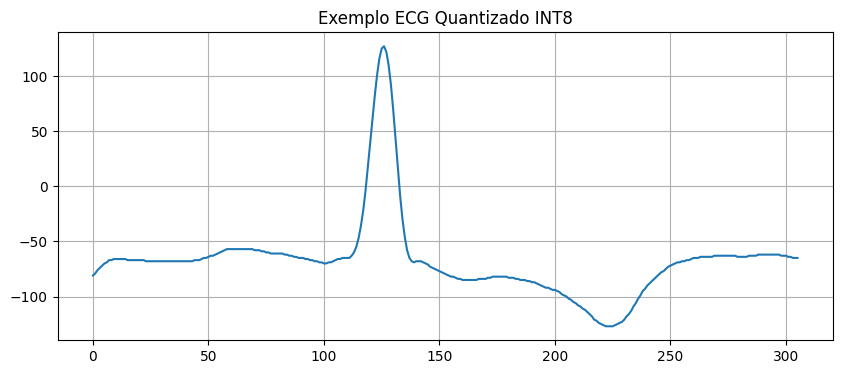


Gerando CSV STM32...

CSV gerado:
/kaggle/working/test_int8_sem_balanceamento.csv


In [ ]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import pandas as pd
import neurokit2 as nk

# ==========================================================
# CONFIG
# ==========================================================
print("TF:", tf.__version__)

SAMPLING_RATE = 360
WINDOW_SIZE = 306

TARGET_CLASSES = ['N', 'L', 'R', 'V', 'A']

LABEL_TO_INDEX = {
    l:i for i,l in enumerate(TARGET_CLASSES)
}

INDEX_TO_LABEL = {
    i:l for l,i in LABEL_TO_INDEX.items()
}

data_path = '/kaggle/input/mit-bih'

record_list = [
    f.replace('.dat','')
    for f in os.listdir(data_path)
    if f.endswith('.dat')
]

# ==========================================================
# FILTRAGEM
# ==========================================================
signals = {}
annots = {}

print("\nFiltrando sinais...")

for r in record_list:

    try:

        path = os.path.join(data_path, r)

        rec = wfdb.rdrecord(path)
        ann = wfdb.rdann(path, 'atr')

        sig = rec.p_signal[:,0]

        # Filtragem ECG
        sig = nk.ecg_clean(
            sig,
            sampling_rate=SAMPLING_RATE
        )

        signals[r] = sig
        annots[r] = ann

    except Exception as e:

        print("Erro:", r, e)

# ==========================================================
# SEGMENTAÇÃO
# ==========================================================
X = []
y = []

print("\nSegmentando...")

for r in record_list:

    if r not in signals:
        continue

    sig = signals[r]
    ann = annots[r]

    for i, p in enumerate(ann.sample):

        if ann.symbol[i] in TARGET_CLASSES:

            s = p - 126
            e = p + 180

            if s < 0 or e >= len(sig):
                continue

            seg = sig[s:e]

            if len(seg) == WINDOW_SIZE:

                X.append(seg)

                y.append(
                    LABEL_TO_INDEX[
                        ann.symbol[i]
                    ]
                )

X = np.array(X)
y = np.array(y)

print("\nDistribuição original:")
print(Counter(y))

# ==========================================================
# NORMALIZAÇÃO
# ==========================================================
print("\nNormalizando...")

Xn = np.zeros_like(
    X,
    dtype=np.float32
)

for i in range(len(X)):

    mn = np.min(X[i])
    mx = np.max(X[i])

    if mx - mn == 0:
        Xn[i] = 0
    else:
        Xn[i] = (
            X[i] - mn
        ) / (mx - mn)

X = Xn

# ==========================================================
# SPLIT 60/20/20
# ==========================================================
print("\nSplit 60/20/20")

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("\nTrain:")
print(Counter(y_train))

print("\nVal:")
print(Counter(y_val))

print("\nTest:")
print(Counter(y_test))

# ==========================================================
# NPZ PARA STM32Cube.AI (USANDO DADOS DE TREINO)
# ==========================================================
X_train_npz = X_train[..., np.newaxis]

np.random.seed(42)

n_samples = len(X_train_npz)

idx = np.random.choice(
    n_samples,
    n_samples // 1,
    replace=False
)

X_train_npz_reduced = X_train_npz[idx]
y_train_reduced = y_train[idx]

np.savez(
    "validation_dataset.npz",
    x_test=X_train_npz_reduced.astype(np.float32),
    y_test=y_train_reduced.astype(np.int64)
)

print("\nNPZ gerado com dados de TREINO!")

print("Shape x_test:", X_train_npz_reduced.shape)
print("Shape y_test:", y_train_reduced.shape)
# ==========================================================
# GRÁFICOS DE DISTRIBUIÇÃO
# ==========================================================
def plot_distribution(labels, title):

    counts = Counter(labels)

    classes = [
        INDEX_TO_LABEL[i]
        for i in range(len(TARGET_CLASSES))
    ]

    values = [
        counts.get(i, 0)
        for i in range(len(TARGET_CLASSES))
    ]

    plt.figure(figsize=(8,5))

    plt.bar(
        classes,
        values
    )

    plt.title(title)

    plt.xlabel("Classes")

    plt.ylabel("Quantidade de amostras")

    plt.show()

# ----------------------------------------------------------
# TREINO
# ----------------------------------------------------------
plot_distribution(
    y_train,
    "Distribuição - Treino"
)

# ----------------------------------------------------------
# VALIDAÇÃO
# ----------------------------------------------------------
plot_distribution(
    y_val,
    "Distribuição - Validação"
)

# ----------------------------------------------------------
# TESTE
# ----------------------------------------------------------
plot_distribution(
    y_test,
    "Distribuição - Teste"
)

# ==========================================================
# ONE HOT
# ==========================================================
y_train_cat = to_categorical(
    y_train,
    len(TARGET_CLASSES)
)

y_val_cat = to_categorical(
    y_val,
    len(TARGET_CLASSES)
)

y_test_cat = to_categorical(
    y_test,
    len(TARGET_CLASSES)
)

# ==========================================================
# AJUSTE DE DIMENSÃO CNN
# ==========================================================
X_train_cnn = X_train[...,None]
X_val_cnn = X_val[...,None]
X_test_cnn = X_test[...,None]

# =========================================================
# MODELO CNN
# =========================================================

print("\n================ MODELO ================\n")

inputs = Input(shape=(WINDOW_SIZE, 1))
x = Conv1D(8,5,activation='relu')(inputs)
x = MaxPooling1D(2)(x)
x = Dropout(0.25)(x)
x = Conv1D(16,5,activation='relu')(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.25)(x)
x = Flatten()(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(5,activation='softmax')(x)
model = Model(inputs, outputs)
model.compile( optimizer=Adam(0.001),loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

# ==========================================================
# TREINAMENTO
# ==========================================================
print("\nTreinando...")

history = model.fit(
    X_train_cnn,
    y_train_cat,
    epochs=20,
    batch_size=32,
    validation_data=(
        X_val_cnn,
        y_val_cat
    ),
    verbose=1
)

# ==========================================================
# SALVAR MODELO
# ==========================================================
print("\nSalvando modelo...")

MODEL_NAME = "modelo_ecg_sem_balanceamento_final.h5"

model.save(MODEL_NAME)

print(
    f"\nModelo salvo como: {MODEL_NAME}"
)

# ==========================================================
# TESTAR CARREGAMENTO
# ==========================================================
print("\nTestando carregamento...")

loaded_model = load_model(MODEL_NAME)

print("Modelo carregado com sucesso!")

# ==========================================================
# AVALIAÇÃO
# ==========================================================
print("\nAvaliando teste real...")

y_pred = np.argmax(
    loaded_model.predict(
        X_test_cnn
    ),
    axis=1
)

y_true = y_test

cm = confusion_matrix(
    y_true,
    y_pred
)

ConfusionMatrixDisplay(
    cm,
    display_labels=TARGET_CLASSES
).plot(cmap='Blues')

plt.title("Teste real")
plt.show()

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=TARGET_CLASSES
    )
)

# ==========================================================
# SALVAR CLASSIFICATION REPORT
# ==========================================================
report = classification_report(
    y_true,
    y_pred,
    target_names=TARGET_CLASSES,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

df_report.to_csv(
    "classification_report_sem_balanceamento.csv"
)

print(
    "\nRelatório salvo!"
)

# ==========================================================
# SALVAR MATRIZ DE CONFUSÃO
# ==========================================================
cm_df = pd.DataFrame(
    cm,
    index=TARGET_CLASSES,
    columns=TARGET_CLASSES
)

cm_df.to_csv(
    "confusion_matrix_sem_balanceamento.csv"
)

print(
    "Matriz de confusão salva!"
)

# ==========================================================
# QUANTIZAÇÃO INT8
# ==========================================================
print("\nQuantização INT8")

X_test_flat = X_test_cnn.squeeze(-1)

Xc = X_test_flat - 0.5

X_int8 = np.clip(
    np.round(Xc * 254),
    -127,
    127
).astype(np.int8)

print("Shape:", X_int8.shape)

# ==========================================================
# VISUALIZAÇÃO
# ==========================================================
plt.figure(figsize=(10,4))

plt.plot(X_int8[0])

plt.title(
    "Exemplo ECG Quantizado INT8"
)

plt.grid()

plt.show()

# ==========================================================
# CSV STM32
# ==========================================================
print("\nGerando CSV STM32...")

df = pd.DataFrame(
    X_int8,
    columns=[
        f"p{i}"
        for i in range(WINDOW_SIZE)
    ]
)

df["label"] = y_test

df.to_csv(
    "/kaggle/working/test_int8_sem_balanceamento.csv",
    index=False
)

print(
    "\nCSV gerado:"
)

print(
    "/kaggle/working/test_int8_sem_balanceamento.csv"
)

### Under + Over:

TF: 2.15.0

Filtrando sinais...

Segmentando...

Original:
Counter({0: 75017, 1: 8071, 2: 7255, 3: 7129, 4: 2546})

Normalizando...

Undersampling classe N...

Após undersampling:
Counter({0: 9000, 1: 8071, 2: 7255, 3: 7129, 4: 2546})

Split 60/20/20

Train:
Counter({0: 5400, 1: 4842, 2: 4353, 3: 4277, 4: 1528})

Val:
Counter({0: 1800, 1: 1614, 2: 1451, 3: 1426, 4: 509})

Test:
Counter({0: 1800, 1: 1615, 2: 1451, 3: 1426, 4: 509})
NPZ gerado com dados de TREINO!
Shape x_test: (20400, 306, 1)
Shape y_test: (20400,)


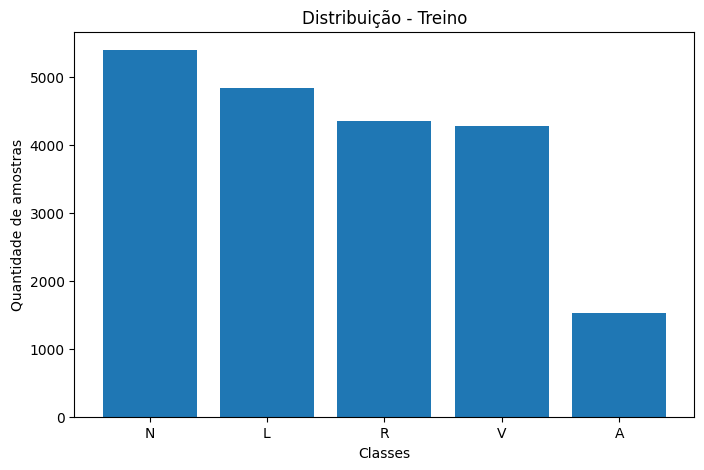

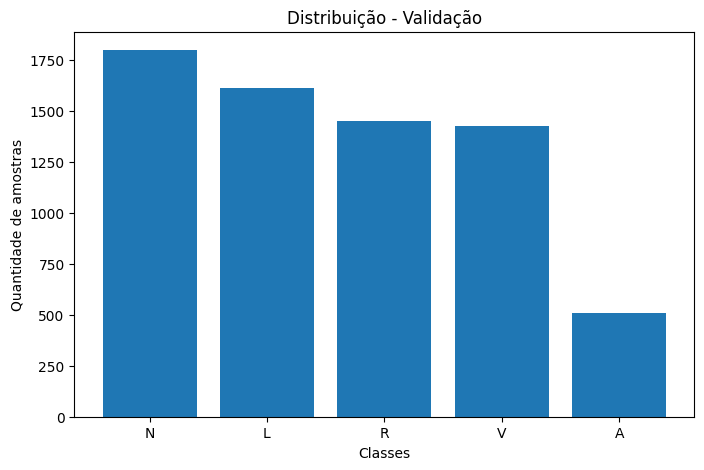

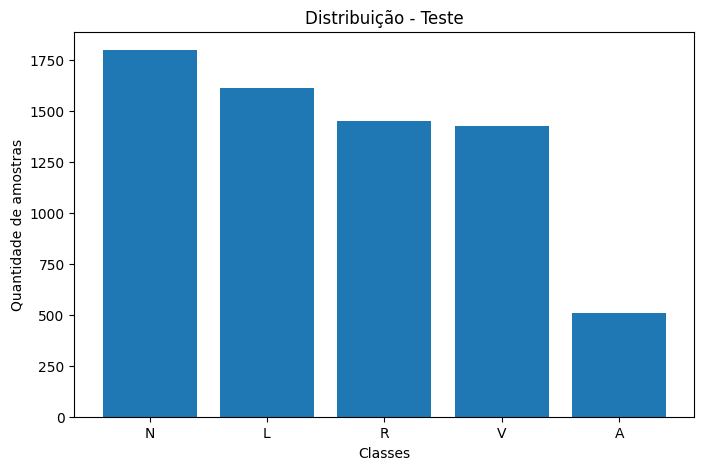


Aplicando SMOTE no treino...

Após SMOTE:
Counter({0: 5400, 1: 5400, 2: 5400, 3: 5400, 4: 5400})


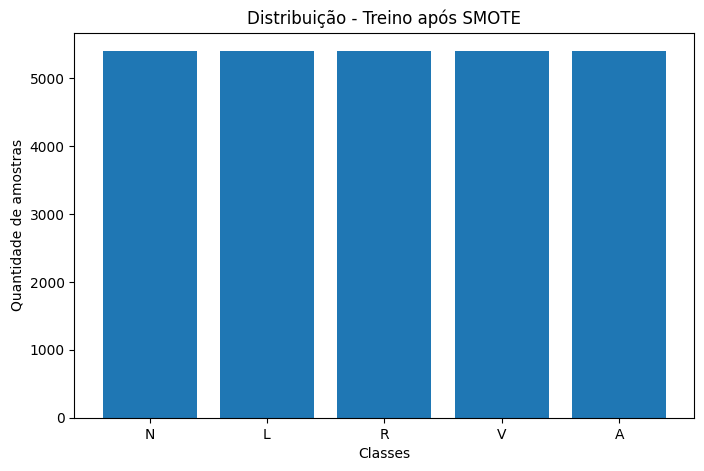


================ MODELO ================

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 306, 1)]          0         
                                                                 
 conv1d_4 (Conv1D)           (None, 302, 8)            48        
                                                                 
 max_pooling1d_4 (MaxPoolin  (None, 151, 8)            0         
 g1D)                                                            
                                                                 
 dropout_6 (Dropout)         (None, 151, 8)            0         
                                                                 
 conv1d_5 (Conv1D)           (None, 147, 16)           656       
                                                                 
 max_pooling1d_5 (MaxPoolin  (None, 73, 16)            0         
 g1D)           

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


213/213 [==============================] - 1s 4ms/step


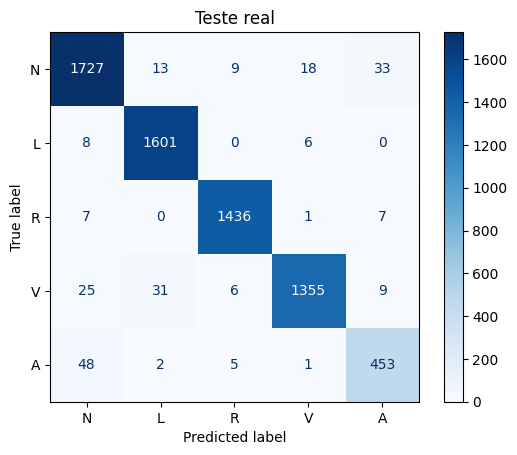


Classification Report:

              precision    recall  f1-score   support

           N       0.95      0.96      0.96      1800
           L       0.97      0.99      0.98      1615
           R       0.99      0.99      0.99      1451
           V       0.98      0.95      0.97      1426
           A       0.90      0.89      0.90       509

    accuracy                           0.97      6801
   macro avg       0.96      0.96      0.96      6801
weighted avg       0.97      0.97      0.97      6801


Relatório salvo!
Matriz de confusão salva!

Quantização INT8
Shape: (6801, 306)


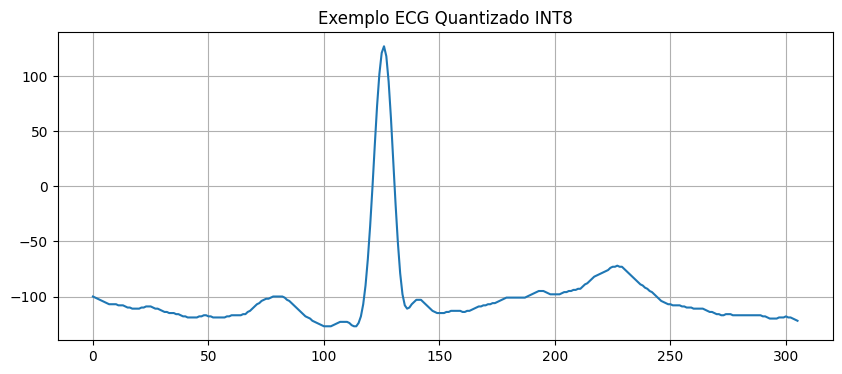


Gerando CSV STM32...

CSV gerado:
/kaggle/working/test_int8_undersampling10k_smote.csv


In [ ]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import pandas as pd
import neurokit2 as nk

# ==========================================================
# CONFIG
# ==========================================================
print("TF:", tf.__version__)

SAMPLING_RATE = 360
WINDOW_SIZE = 306

TARGET_CLASSES = ['N', 'L', 'R', 'V', 'A']

LABEL_TO_INDEX = {
    l:i for i,l in enumerate(TARGET_CLASSES)
}

INDEX_TO_LABEL = {
    i:l for l,i in LABEL_TO_INDEX.items()
}

data_path = '/kaggle/input/mit-bih'

record_list = [
    f.replace('.dat','')
    for f in os.listdir(data_path)
    if f.endswith('.dat')
]

# ==========================================================
# FILTRAGEM
# ==========================================================
signals = {}
annots = {}

print("\nFiltrando sinais...")

for r in record_list:

    try:

        path = os.path.join(data_path, r)

        rec = wfdb.rdrecord(path)
        ann = wfdb.rdann(path, 'atr')

        sig = rec.p_signal[:,0]

        # Filtragem ECG
        sig = nk.ecg_clean(
            sig,
            sampling_rate=SAMPLING_RATE
        )

        signals[r] = sig
        annots[r] = ann

    except Exception as e:

        print("Erro:", r, e)

# ==========================================================
# SEGMENTAÇÃO
# ==========================================================
X = []
y = []

print("\nSegmentando...")

for r in record_list:

    if r not in signals:
        continue

    sig = signals[r]
    ann = annots[r]

    for i, p in enumerate(ann.sample):

        if ann.symbol[i] in TARGET_CLASSES:

            s = p - 126
            e = p + 180

            if s < 0 or e >= len(sig):
                continue

            seg = sig[s:e]

            if len(seg) == WINDOW_SIZE:

                X.append(seg)

                y.append(
                    LABEL_TO_INDEX[
                        ann.symbol[i]
                    ]
                )

X = np.array(X)
y = np.array(y)

print("\nOriginal:")
print(Counter(y))

# ==========================================================
# NORMALIZAÇÃO
# ==========================================================
print("\nNormalizando...")

Xn = np.zeros_like(
    X,
    dtype=np.float32
)

for i in range(len(X)):

    mn = np.min(X[i])
    mx = np.max(X[i])

    if mx - mn == 0:
        Xn[i] = 0
    else:
        Xn[i] = (
            X[i] - mn
        ) / (mx - mn)

X = Xn

# ==========================================================
# UNDERSAMPLING CLASSE N
# ==========================================================
print("\nUndersampling classe N...")

N_CLASS = LABEL_TO_INDEX['N']

idx_n = np.where(y == N_CLASS)[0]
idx_other = np.where(y != N_CLASS)[0]

np.random.seed(42)

idx_n_selected = np.random.choice(
    idx_n,
    size=9000,
    replace=False
)

idx_final = np.concatenate([
    idx_n_selected,
    idx_other
])

np.random.shuffle(idx_final)

X = X[idx_final]
y = y[idx_final]

print("\nApós undersampling:")
print(Counter(y))

# ==========================================================
# SPLIT 60/20/20
# ==========================================================
print("\nSplit 60/20/20")

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("\nTrain:")
print(Counter(y_train))

print("\nVal:")
print(Counter(y_val))

print("\nTest:")
print(Counter(y_test))

# NPZ PARA STM32Cube.AI (USANDO DADOS DE TREINO)

X_train_npz = X_train[..., np.newaxis]

# reduzir para não ficar pesado no site (mantendo representatividade)
np.random.seed(42)

n_samples = len(X_train_npz)
idx = np.random.choice(n_samples, n_samples // 1, replace=False)

X_train_npz_reduced = X_train_npz[idx]
y_train_reduced = y_train[idx]

np.savez(
    "validation_dataset.npz",
    x_test=X_train_npz_reduced.astype(np.float32),
    y_test=y_train_reduced.astype(np.int64)
)

print("NPZ gerado com dados de TREINO!")
print("Shape x_test:", X_train_npz_reduced.shape)
print("Shape y_test:", y_train_reduced.shape)

# ==========================================================
# GRÁFICOS DE DISTRIBUIÇÃO
# ==========================================================
def plot_distribution(labels, title):

    counts = Counter(labels)

    classes = [
        INDEX_TO_LABEL[i]
        for i in range(len(TARGET_CLASSES))
    ]

    values = [
        counts.get(i, 0)
        for i in range(len(TARGET_CLASSES))
    ]

    plt.figure(figsize=(8,5))

    plt.bar(
        classes,
        values
    )

    plt.title(title)

    plt.xlabel("Classes")

    plt.ylabel("Quantidade de amostras")

    plt.show()

# ----------------------------------------------------------
# TREINO
# ----------------------------------------------------------
plot_distribution(
    y_train,
    "Distribuição - Treino"
)

# ----------------------------------------------------------
# VALIDAÇÃO
# ----------------------------------------------------------
plot_distribution(
    y_val,
    "Distribuição - Validação"
)

# ----------------------------------------------------------
# TESTE
# ----------------------------------------------------------
plot_distribution(
    y_test,
    "Distribuição - Teste"
)
# ==========================================================
# ONE HOT
# ==========================================================
y_train_cat = to_categorical(
    y_train,
    len(TARGET_CLASSES)
)

y_val_cat = to_categorical(
    y_val,
    len(TARGET_CLASSES)
)

y_test_cat = to_categorical(
    y_test,
    len(TARGET_CLASSES)
)

# ==========================================================
# SMOTE APENAS NO TREINO
# ==========================================================
print("\nAplicando SMOTE no treino...")

X_train_flat = X_train.reshape(
    len(X_train),
    -1
)

smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(
    X_train_flat,
    y_train
)

X_res = X_res.reshape(
    -1,
    WINDOW_SIZE,
    1
)

y_res_cat = to_categorical(
    y_res,
    len(TARGET_CLASSES)
)

print("\nApós SMOTE:")
print(Counter(y_res))
# ==========================================================
# DISTRIBUIÇÃO APÓS SMOTE
# ==========================================================
plot_distribution(
    y_res,
    "Distribuição - Treino após SMOTE"
)


# =========================================================
# MODELO CNN
# =========================================================

print("\n================ MODELO ================\n")

inputs = Input(shape=(WINDOW_SIZE, 1))
x = Conv1D(8,5,activation='relu')(inputs)
x = MaxPooling1D(2)(x)
x = Dropout(0.25)(x)
x = Conv1D(16,5,activation='relu')(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.25)(x)
x = Flatten()(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(5,activation='softmax')(x)
model = Model(inputs, outputs)
model.compile( optimizer=Adam(0.001),loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()
# ==========================================================
# TREINAMENTO
# ==========================================================
print("\nTreinando...")

history = model.fit(
    X_res,
    y_res_cat,
    epochs=20,
    batch_size=32,
    validation_data=(
        X_val[...,None],
        y_val_cat
    ),
    verbose=1
)

# ==========================================================
# SALVAR MODELO
# ==========================================================
print("\nSalvando modelo...")

MODEL_NAME = "modelo_ecg_undersampling10k_smote_final.h5"

model.save(MODEL_NAME)

print(
    f"\nModelo salvo como: {MODEL_NAME}"
)

# ==========================================================
# TESTAR CARREGAMENTO
# ==========================================================
print("\nTestando carregamento...")

loaded_model = load_model(MODEL_NAME)

print("Modelo carregado com sucesso!")

# ==========================================================
# AVALIAÇÃO
# ==========================================================
print("\nAvaliando teste real...")

y_pred = np.argmax(
    loaded_model.predict(
        X_test[...,None]
    ),
    axis=1
)

y_true = y_test

cm = confusion_matrix(
    y_true,
    y_pred
)

ConfusionMatrixDisplay(
    cm,
    display_labels=TARGET_CLASSES
).plot(cmap='Blues')

plt.title("Teste real")
plt.show()

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=TARGET_CLASSES
    )
)

# ==========================================================
# SALVAR CLASSIFICATION REPORT
# ==========================================================
report = classification_report(
    y_true,
    y_pred,
    target_names=TARGET_CLASSES,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

df_report.to_csv(
    "classification_report_undersampling10k_smote.csv"
)

print(
    "\nRelatório salvo!"
)

# ==========================================================
# SALVAR MATRIZ DE CONFUSÃO
# ==========================================================
cm_df = pd.DataFrame(
    cm,
    index=TARGET_CLASSES,
    columns=TARGET_CLASSES
)

cm_df.to_csv(
    "confusion_matrix_undersampling10k_smote.csv"
)

print(
    "Matriz de confusão salva!"
)

# ==========================================================
# QUANTIZAÇÃO INT8
# ==========================================================
print("\nQuantização INT8")

X_test_flat = X_test[...,None].squeeze(-1)

Xc = X_test_flat - 0.5

X_int8 = np.clip(
    np.round(Xc * 254),
    -127,
    127
).astype(np.int8)

print("Shape:", X_int8.shape)

# ==========================================================
# VISUALIZAÇÃO
# ==========================================================
plt.figure(figsize=(10,4))

plt.plot(X_int8[0])

plt.title(
    "Exemplo ECG Quantizado INT8"
)

plt.grid()

plt.show()

# ==========================================================
# CSV STM32
# ==========================================================
print("\nGerando CSV STM32...")

df = pd.DataFrame(
    X_int8,
    columns=[
        f"p{i}"
        for i in range(WINDOW_SIZE)
    ]
)

df["label"] = y_test

df.to_csv(
    "/kaggle/working/test_int8_undersampling10k_smote.csv",
    index=False
)

print(
    "\nCSV gerado:"
)

print(
    "/kaggle/working/test_int8_undersampling10k_smote.csv"
)

### Under:

TF: 2.15.0

Filtrando sinais...

Segmentando...

Original:
Counter({0: 75017, 1: 8071, 2: 7255, 3: 7129, 4: 2546})

Normalizando...

Balanceamento global...

Classe N
Original: 75017

Classe L
Original: 8071

Classe R
Original: 7255

Classe V
Original: 7129

Classe A
Original: 2546

Após balanceamento:
Counter({1: 2546, 3: 2546, 4: 2546, 2: 2546, 0: 2546})

Split 60/20/20

Train:
Counter({2: 1528, 1: 1528, 4: 1528, 0: 1527, 3: 1527})

Val:
Counter({3: 510, 4: 509, 0: 509, 2: 509, 1: 509})

Test:
Counter({0: 510, 2: 509, 3: 509, 4: 509, 1: 509})
NPZ salvo com 50% das amostras!
Shape x_test: (848, 306, 1)
Shape y_test: (848,)

Treino sem SMOTE
Counter({2: 1528, 1: 1528, 4: 1528, 0: 1527, 3: 1527})

================ MODELO ================

Model: "model_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 306, 1)]          0         
                                     

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


80/80 [==============================] - 0s 4ms/step


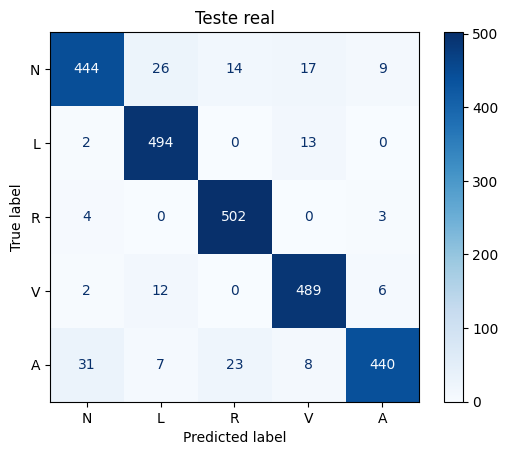


Classification Report:

              precision    recall  f1-score   support

           N       0.92      0.87      0.89       510
           L       0.92      0.97      0.94       509
           R       0.93      0.99      0.96       509
           V       0.93      0.96      0.94       509
           A       0.96      0.86      0.91       509

    accuracy                           0.93      2546
   macro avg       0.93      0.93      0.93      2546
weighted avg       0.93      0.93      0.93      2546


Relatório salvo!
Matriz de confusão salva!

Quantização INT8
Shape: (2546, 306)


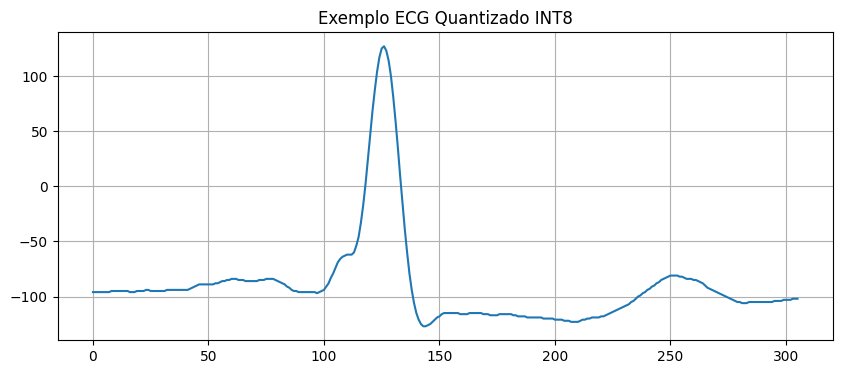


Gerando CSV STM32...

CSV gerado:
/kaggle/working/test_int8_balanceado_2546.csv


In [ ]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import pandas as pd
import neurokit2 as nk

# ==========================================================
# CONFIG
# ==========================================================
print("TF:", tf.__version__)

SAMPLING_RATE = 360
WINDOW_SIZE = 306

TARGET_CLASSES = ['N', 'L', 'R', 'V', 'A']

LABEL_TO_INDEX = {
    l:i for i,l in enumerate(TARGET_CLASSES)
}

INDEX_TO_LABEL = {
    i:l for l,i in LABEL_TO_INDEX.items()
}

data_path = '/kaggle/input/mit-bih'

record_list = [
    f.replace('.dat','')
    for f in os.listdir(data_path)
    if f.endswith('.dat')
]

# ==========================================================
# FILTRAGEM
# ==========================================================
signals = {}
annots = {}

print("\nFiltrando sinais...")

for r in record_list:

    try:

        path = os.path.join(data_path, r)

        rec = wfdb.rdrecord(path)
        ann = wfdb.rdann(path, 'atr')

        sig = rec.p_signal[:,0]

        # Filtragem ECG
        sig = nk.ecg_clean(
            sig,
            sampling_rate=SAMPLING_RATE
        )

        signals[r] = sig
        annots[r] = ann

    except Exception as e:

        print("Erro:", r, e)

# ==========================================================
# SEGMENTAÇÃO
# ==========================================================
X = []
y = []

print("\nSegmentando...")

for r in record_list:

    if r not in signals:
        continue

    sig = signals[r]
    ann = annots[r]

    for i, p in enumerate(ann.sample):

        if ann.symbol[i] in TARGET_CLASSES:

            s = p - 126
            e = p + 180

            if s < 0 or e >= len(sig):
                continue

            seg = sig[s:e]

            if len(seg) == WINDOW_SIZE:

                X.append(seg)

                y.append(
                    LABEL_TO_INDEX[
                        ann.symbol[i]
                    ]
                )

X = np.array(X)
y = np.array(y)

print("\nOriginal:")
print(Counter(y))

# ==========================================================
# NORMALIZAÇÃO
# ==========================================================
print("\nNormalizando...")

Xn = np.zeros_like(
    X,
    dtype=np.float32
)

for i in range(len(X)):

    mn = np.min(X[i])
    mx = np.max(X[i])

    if mx - mn == 0:
        Xn[i] = 0
    else:
        Xn[i] = (
            X[i] - mn
        ) / (mx - mn)

X = Xn

# ==========================================================
# BALANCEAMENTO GLOBAL
# TODAS AS CLASSES -> 2546
# ==========================================================
print("\nBalanceamento global...")

TARGET_SAMPLES = 2546

np.random.seed(42)

X_bal = []
y_bal = []

for cls in range(len(TARGET_CLASSES)):

    idx_cls = np.where(y == cls)[0]

    print(
        f"\nClasse {INDEX_TO_LABEL[cls]}"
    )

    print(
        f"Original: {len(idx_cls)}"
    )

    # ======================================================
    # UNDERSAMPLING
    # ======================================================
    if len(idx_cls) > TARGET_SAMPLES:

        idx_selected = np.random.choice(
            idx_cls,
            size=TARGET_SAMPLES,
            replace=False
        )

    # ======================================================
    # OVERSAMPLING
    # ======================================================
    else:

        idx_selected = np.random.choice(
            idx_cls,
            size=TARGET_SAMPLES,
            replace=True
        )

    X_bal.append(X[idx_selected])
    y_bal.append(y[idx_selected])

X = np.concatenate(
    X_bal,
    axis=0
)

y = np.concatenate(
    y_bal,
    axis=0
)

# Embaralhar
idx_shuffle = np.random.permutation(len(X))

X = X[idx_shuffle]
y = y[idx_shuffle]

print("\nApós balanceamento:")
print(Counter(y))

# ==========================================================
# SPLIT 60/20/20
# ==========================================================
print("\nSplit 60/20/20")

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("\nTrain:")
print(Counter(y_train))

print("\nVal:")
print(Counter(y_val))

print("\nTest:")
print(Counter(y_test))
# ==========================================================
# NPZ PARA STM32Cube.AI (REDUZIDO PELA METADE)
# ==========================================================

X_val_npz = X_val[..., np.newaxis]

# ==========================================================
# REDUZIR 50% DAS AMOSTRAS
# ==========================================================

np.random.seed(42)

n_samples = len(X_val_npz)
idx = np.random.choice(n_samples, n_samples // 3, replace=False)

X_val_npz_reduced = X_val_npz[idx]
y_val_reduced = y_val[idx]

np.savez(
    "validation_dataset.npz",
    x_test=X_val_npz_reduced.astype(np.float32),
    y_test=y_val_reduced.astype(np.int64)
)

print("NPZ salvo com 50% das amostras!")
print("Shape x_test:", X_val_npz_reduced.shape)
print("Shape y_test:", y_val_reduced.shape)

# ==========================================================
# ONE HOT
# ==========================================================
y_train_cat = to_categorical(
    y_train,
    len(TARGET_CLASSES)
)

y_val_cat = to_categorical(
    y_val,
    len(TARGET_CLASSES)
)

y_test_cat = to_categorical(
    y_test,
    len(TARGET_CLASSES)
)

# ==========================================================
# SEM SMOTE
# ==========================================================
print("\nTreino sem SMOTE")

X_res = X_train[...,None]
y_res_cat = y_train_cat

print(Counter(y_train))

# =========================================================
# MODELO CNN
# =========================================================

print("\n================ MODELO ================\n")

inputs = Input(shape=(WINDOW_SIZE, 1))
x = Conv1D(8,5,activation='relu')(inputs)
x = MaxPooling1D(2)(x)
x = Dropout(0.25)(x)
x = Conv1D(16,5,activation='relu')(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.25)(x)
x = Flatten()(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(5,activation='softmax')(x)
model = Model(inputs, outputs)
model.compile( optimizer=Adam(0.001),loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()


# ==========================================================
# TREINAMENTO
# ==========================================================
print("\nTreinando...")

history = model.fit(
    X_res,
    y_res_cat,
    epochs=20,
    batch_size=32,
    validation_data=(
        X_val[...,None],
        y_val_cat
    ),
    verbose=1
)

# ==========================================================
# SALVAR MODELO
# ==========================================================
print("\nSalvando modelo...")

MODEL_NAME = "modelo_ecg_balanceado_2546_final.h5"

model.save(MODEL_NAME)

print(
    f"\nModelo salvo como: {MODEL_NAME}"
)

# ==========================================================
# TESTAR CARREGAMENTO
# ==========================================================
print("\nTestando carregamento...")

loaded_model = load_model(MODEL_NAME)

print("Modelo carregado com sucesso!")

# ==========================================================
# AVALIAÇÃO
# ==========================================================
print("\nAvaliando teste real...")

y_pred = np.argmax(
    loaded_model.predict(
        X_test[...,None]
    ),
    axis=1
)

y_true = y_test

cm = confusion_matrix(
    y_true,
    y_pred
)

ConfusionMatrixDisplay(
    cm,
    display_labels=TARGET_CLASSES
).plot(cmap='Blues')

plt.title("Teste real")
plt.show()

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=TARGET_CLASSES
    )
)

# ==========================================================
# SALVAR CLASSIFICATION REPORT
# ==========================================================
report = classification_report(
    y_true,
    y_pred,
    target_names=TARGET_CLASSES,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

df_report.to_csv(
    "classification_report_balanceado.csv"
)

print(
    "\nRelatório salvo!"
)

# ==========================================================
# SALVAR MATRIZ DE CONFUSÃO
# ==========================================================
cm_df = pd.DataFrame(
    cm,
    index=TARGET_CLASSES,
    columns=TARGET_CLASSES
)

cm_df.to_csv(
    "confusion_matrix_balanceado.csv"
)

print(
    "Matriz de confusão salva!"
)

# ==========================================================
# QUANTIZAÇÃO INT8
# ==========================================================
print("\nQuantização INT8")

X_test_flat = X_test[...,None].squeeze(-1)

Xc = X_test_flat - 0.5

X_int8 = np.clip(
    np.round(Xc * 254),
    -127,
    127
).astype(np.int8)

print("Shape:", X_int8.shape)

# ==========================================================
# VISUALIZAÇÃO
# ==========================================================
plt.figure(figsize=(10,4))

plt.plot(X_int8[0])

plt.title(
    "Exemplo ECG Quantizado INT8"
)

plt.grid()

plt.show()

# ==========================================================
# CSV STM32
# ==========================================================
print("\nGerando CSV STM32...")

df = pd.DataFrame(
    X_int8,
    columns=[
        f"p{i}"
        for i in range(WINDOW_SIZE)
    ]
)

df["label"] = y_test

df.to_csv(
    "/kaggle/working/test_int8_balanceado_2546.csv",
    index=False
)

print(
    "\nCSV gerado:"
)

print(
    "/kaggle/working/test_int8_balanceado_2546.csv"
)

### Testes embarcados:

### Desbalanceado:



   real  pred
0     0     0
1     2     2
2     0     0
3     2     2
4     0     0


<Figure size 700x600 with 0 Axes>

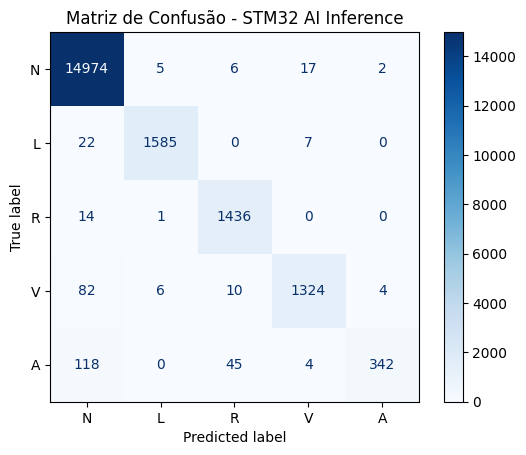


===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           N       0.98      1.00      0.99     15004
           L       0.99      0.98      0.99      1614
           R       0.96      0.99      0.97      1451
           V       0.98      0.93      0.95      1426
           A       0.98      0.67      0.80       509

    accuracy                           0.98     20004
   macro avg       0.98      0.91      0.94     20004
weighted avg       0.98      0.98      0.98     20004



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# ==========================
# CARREGAR CSV GERADO PELO STM32
# ==========================
# ajuste o caminho conforme upload no Kaggle
df = pd.read_csv("/kaggle/input/datasets/felipebastos123/predicoes-final/predicoes_stm32_sem_balanceamento_final.csv")

print(df.head())

# ==========================
# SEPARAR VETORES
# ==========================
y_real = df["real"].values
y_pred = df["pred"].values

# ==========================
# MATRIZ DE CONFUSÃO
# ==========================
labels = [0, 1, 2, 3, 4]  # ajuste se suas classes forem outras

cm = confusion_matrix(y_real, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["N", "L", "R", "V", "A"]
)

plt.figure(figsize=(7, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão - STM32 AI Inference")
plt.show()

# ==========================
# RELATÓRIO COMPLETO
# ==========================
print("\n===== CLASSIFICATION REPORT =====\n")

print(classification_report(
    y_real,
    y_pred,
    labels=labels,
    target_names=["N", "L", "R", "V", "A"]
))

### Under:

   real  pred
0     2     2
1     0     0
2     3     3
3     4     4
4     4     4


<Figure size 700x600 with 0 Axes>

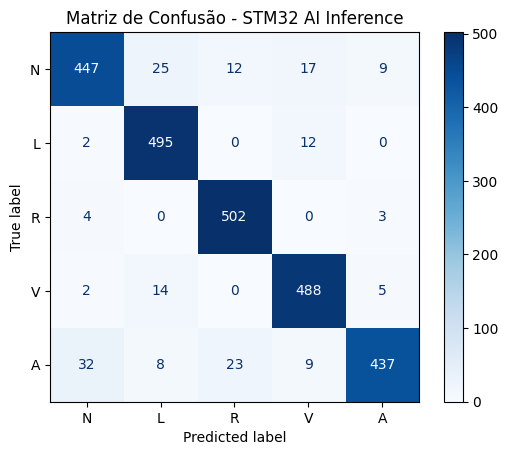


===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           N       0.92      0.88      0.90       510
           L       0.91      0.97      0.94       509
           R       0.93      0.99      0.96       509
           V       0.93      0.96      0.94       509
           A       0.96      0.86      0.91       509

    accuracy                           0.93      2546
   macro avg       0.93      0.93      0.93      2546
weighted avg       0.93      0.93      0.93      2546



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# ==========================
# CARREGAR CSV GERADO PELO STM32
# ==========================
# ajuste o caminho conforme upload no Kaggle
df = pd.read_csv("/kaggle/input/datasets/felipebastos123/predicoes-under/predicoes_stm32_under.csv")

print(df.head())

# ==========================
# SEPARAR VETORES
# ==========================
y_real = df["real"].values
y_pred = df["pred"].values

# ==========================
# MATRIZ DE CONFUSÃO
# ==========================
labels = [0, 1, 2, 3, 4]  # ajuste se suas classes forem outras

cm = confusion_matrix(y_real, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["N", "L", "R", "V", "A"]
)

plt.figure(figsize=(7, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão - STM32 AI Inference")
plt.show()

# ==========================
# RELATÓRIO COMPLETO
# ==========================
print("\n===== CLASSIFICATION REPORT =====\n")

print(classification_report(
    y_real,
    y_pred,
    labels=labels,
    target_names=["N", "L", "R", "V", "A"]
))